![A beautiful sunset](./30%20day%20VIX%20futures%20performance.jpg)

<font size=4>

- Performance of a VIX futures that constantly behaves as it has 30 days to expiry.  
- Portfolio is constructed by taking a linear combination of the front and back monthly contracts, such that the weighted time to expiry is roughly 30 days.
- Calculated using implied VIX forward prices from the an option/forwards pricing table from Option Metrics, downloaded from WRDS through the Cornell Library.
- Data issues handled in below in the notebook using SQL, portfolio calculated from my custom made `derivatives_rebalancer` library.
- `derivatives_rebalancer` repo: https://github.com/FlyingCurryMonster/derivatives-rebalancer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import clickhouse_connect
from derivatives_rebalancer.constant_tte_future import ConstantTTEFuture
import pandas_market_calendars as mcal

%load_ext autoreload
%autoreload 2

# Load data into a Clickhouse view

In [2]:
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username='default',
    password='',
)

client.command("CREATE DATABASE IF NOT EXISTS constant_tte_research")

# secid = 117801 is VIX futures
client.command("""
    CREATE OR REPLACE VIEW constant_tte_research.vix_forward_prices AS
    SELECT
        forward_prices.*,
        expiry_labels.expiry_indicator
    FROM option_metrics.forward_price AS forward_prices
    LEFT JOIN (
        SELECT DISTINCT
            exdate AS expiration,
            expiry_indicator
        FROM option_metrics.option_pricing
        WHERE secid = 117801
          AND am_settlement = 1
    ) AS expiry_labels USING (expiration)
    WHERE forward_prices.secid = 117801
      AND forward_prices.AMSettlement = 1
    ORDER BY expiration, date
""")


# Expiry series exploration

<font size=4>

confirmed expiry_indicator != 'w' are monthly contracts

In [3]:
expiries = client.query_df("""
    SELECT DISTINCT
        exdate AS expiration,
        expiry_indicator
    FROM option_metrics.option_pricing
    WHERE secid = 117801
    ORDER BY exdate, expiry_indicator
""")
expiries['expiry_series'] = expiries['expiry_indicator'].map({'': 'monthly', 'w': 'weekly'})
# expiries['expiration'] = pd.to_datetime(expiries['expiration'])

def get_third_friday(year, month):
    """Third Friday of a given month."""
    first = pd.Timestamp(year, month, 1)
    days_to_friday = (4 - first.dayofweek) % 7
    return first + pd.Timedelta(days=days_to_friday + 14)

def monthly_vix_settlement(year, month):
    """Wednesday 30 days before the third Friday of the following month."""
    if month == 12:
        next_year, next_month = year + 1, 1
    else:
        next_year, next_month = year, month + 1
    return get_third_friday(next_year, next_month) - pd.Timedelta(days=30)

def is_monthly_expiry(expiry, monthly_settlements, tol_days=1):
    """True if expiry is within tol_days of a standard monthly settlement (handles holiday shifts)."""
    return any(abs((expiry - settlement).days) <= tol_days for settlement in monthly_settlements)

years = range(
    expiries['expiration'].min().year - 1,
    expiries['expiration'].max().year + 2,
)
monthly_expiry_rule = pd.DatetimeIndex([
    monthly_vix_settlement(year, month)
    for year in years
    for month in range(1, 13)
])


monthly_expiries = expiries.loc[
    expiries['expiry_series'].eq('monthly'),
    ['expiration', 'expiry_indicator', 'expiry_series'],
].copy()
monthly_expiries['matches_monthly_expiry_rule'] = monthly_expiries['expiration'].map(
    lambda expiration: is_monthly_expiry(
        expiration,
        monthly_expiry_rule,
        tol_days=1,
    )
)

monthly_expiry_rule_exceptions = monthly_expiries.loc[
    ~monthly_expiries['expiration'].isin(monthly_expiry_rule)
]
monthly_expiry_rule_mismatches = monthly_expiries.loc[
    ~monthly_expiries['matches_monthly_expiry_rule']
]

# display(monthly_expiry_rule_exceptions)
# display(monthly_expiry_rule_mismatches)

assert monthly_expiry_rule_mismatches.empty, (
    'Some OptionMetrics monthly expiries do not match the monthly expiry rule '
    'within the one-day holiday tolerance.'
)

# Missing Forward Prices

<font size=5>

- There are zero prices and missing prices in the dataset.
- We can fill in the missing prices with the implied at the money forward.

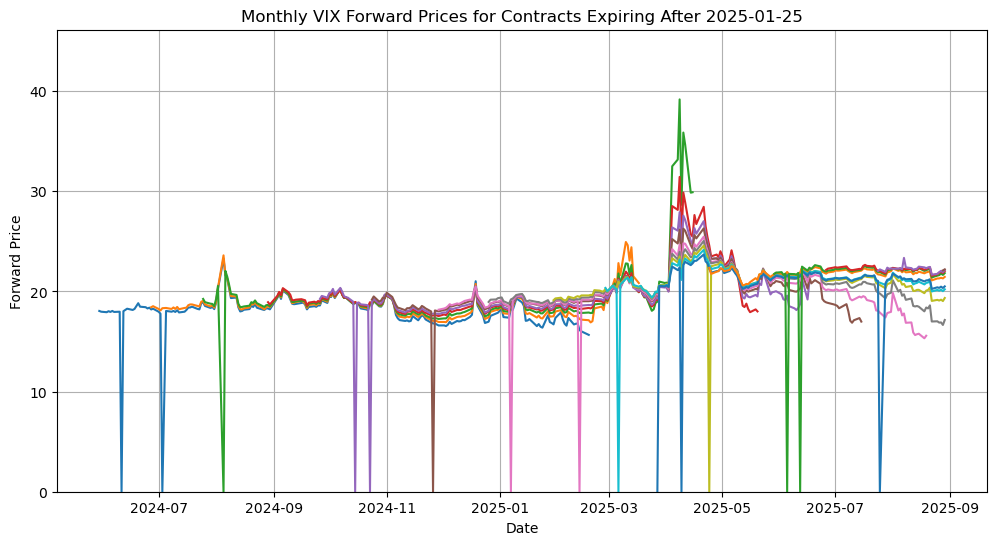

In [4]:
prices_exp2025 = client.query_df("""
    SELECT *
    FROM constant_tte_research.vix_forward_prices
    WHERE expiry_indicator = ''
      AND expiration >= '2025-01-25'
    ORDER BY date, expiration
""")



prices_exp2025['filtered_forward_price'] = prices_exp2025['ForwardPrice'].where(
    prices_exp2025['ForwardPrice'].gt(1.0)
)

fig, ax = plt.subplots(figsize=(12, 6))

for _, contract_prices in prices_exp2025.groupby('expiration', sort=True):
    ax.plot(
        contract_prices['date'],
        contract_prices['ForwardPrice'],linestyle='-')


ax.set_title('Monthly VIX Forward Prices for Contracts Expiring After 2025-01-25')
ax.set_xlabel('Date')
ax.set_ylabel('Forward Price')
ax.set_ylim(0, ax.get_ylim()[1])
ax.grid()

## Imply missing forward price from options pricing

In [5]:
# create ATM implied forwards
client.command("""
    CREATE OR REPLACE VIEW constant_tte_research.atm_implied_forwards AS
    WITH
        deduped_options AS (
            SELECT DISTINCT
                options.optionid,
                options.date,
                options.exdate,
                options.cp_flag,
                options.strike_price,
                options.best_bid,
                options.best_offer
            FROM option_metrics.option_pricing AS options
            WHERE options.secid = 117801
              AND options.am_settlement = 1
        ),
        call_put_pairs AS (
            SELECT
                date,
                exdate,
                strike_price,
                anyIf(best_bid, cp_flag = 'C') AS call_bid,
                anyIf(best_offer, cp_flag = 'C') AS call_offer,
                anyIf(best_bid, cp_flag = 'P') AS put_bid,
                anyIf(best_offer, cp_flag = 'P') AS put_offer
            FROM deduped_options
            GROUP BY
                date,
                exdate,
                strike_price
            HAVING countIf(cp_flag = 'C') = 1
               AND countIf(cp_flag = 'P') = 1
        ),
        parity_by_strike AS (
            SELECT
                date,
                exdate,
                strike_price,
                strike_price / 1000.0
                    + call_bid
                    - put_offer AS forward_bid,
                strike_price / 1000.0
                    + call_offer
                    - put_bid AS forward_offer,
                strike_price / 1000.0
                    + ((call_bid + call_offer) - (put_bid + put_offer)) / 2.0 AS forward_mid,
                abs(((call_bid + call_offer) - (put_bid + put_offer)) / 2.0) AS strike_distance
            FROM call_put_pairs
            WHERE call_bid IS NOT NULL
              AND call_offer IS NOT NULL
              AND put_bid IS NOT NULL
              AND put_offer IS NOT NULL
        )
        
    SELECT
        date,
        exdate AS expiration,
        argMin(
            forward_mid,
            tuple(strike_distance, strike_price)
        ) AS atm_implied_forward_price
    FROM parity_by_strike
    GROUP BY (date, exdate)
    ORDER BY (date, exdate)
""")


# combine original and ATM-implied forward prices
client.command("""
    CREATE OR REPLACE VIEW constant_tte_research.vix_forward_prices_imputed AS
    SELECT
        forward_prices.*,
        implied.atm_implied_forward_price,
        if(
            ifNull(forward_prices.ForwardPrice > 1, false),
            forward_prices.ForwardPrice,
            implied.atm_implied_forward_price
        ) AS filled_forward_price,
        (
            NOT ifNull(forward_prices.ForwardPrice > 1, false)
            AND implied.atm_implied_forward_price IS NOT NULL
        ) AS is_imputed,
        (
            NOT ifNull(forward_prices.ForwardPrice > 1, false)
            AND implied.atm_implied_forward_price IS NULL
        ) AS imputation_failed
    FROM constant_tte_research.vix_forward_prices AS forward_prices
    LEFT JOIN constant_tte_research.atm_implied_forwards AS implied
        USING (date, expiration)
    ORDER BY
        expiration,
        date
""")


# Market calendar alignment

In [6]:
sched = mcal.get_calendar('CFE').schedule(start_date='2003-01-01', end_date='2027-12-31')
sessions = pd.DatetimeIndex(sched.index).normalize()
cal_df = pd.DataFrame({
    'exchange': 'CFE',
    'session_date': sessions.date,           # -> Date32
    'session_index': range(len(sessions)),   # dense 0..N-1, the key trick
})

client.command("""
    CREATE TABLE IF NOT EXISTS constant_tte_research.trading_calendar (
        exchange      LowCardinality(String),
        session_date  Date32,
        session_index UInt32
    ) ENGINE = MergeTree ORDER BY (exchange, session_date)
""")
# Idempotent load: MergeTree never dedupes, so re-running a plain insert_df would
# append a second copy. Only insert this exchange's calendar if it isn't already there.
existing = client.query(
    "SELECT count() FROM constant_tte_research.trading_calendar WHERE exchange = 'CFE'"
).result_rows[0][0]

if existing == 0:
    client.insert_df('constant_tte_research.trading_calendar', cal_df)
    print(f"Inserted {len(cal_df)} CFE sessions.")
elif existing == len(cal_df):
    print(f"CFE calendar already loaded ({existing} rows); skipping insert.")
else:
    print(f"WARNING: CFE has {existing} rows, expected {len(cal_df)}; not inserting "
          f"to avoid duplicates. TRUNCATE TABLE constant_tte_research.trading_calendar to reload.")

client.command(
    """CREATE OR REPLACE VIEW constant_tte_research.vix_forwards_cal_reindex AS
    SELECT
        fp.*,
        cal_e.session_index - cal_d.session_index AS trading_days_to_expiry
    FROM constant_tte_research.vix_forward_prices_imputed AS fp
    LEFT JOIN constant_tte_research.trading_calendar AS cal_d
        ON cal_d.exchange = 'CFE' AND cal_d.session_date = fp.date
    LEFT JOIN constant_tte_research.trading_calendar AS cal_e
        ON cal_e.exchange = 'CFE' AND cal_e.session_date = fp.expiration"""
)

CFE calendar already loaded (6289 rows); skipping insert.


# 30 day constant TTE future

In [ ]:
vix_contract_pricing = client.query_df("""
    SELECT
        expiration AS security,
        date,
        expiration AS expiry,
        filled_forward_price AS futures_price,
        trading_days_to_expiry
    FROM constant_tte_research.vix_forwards_cal_reindex
    WHERE expiry_indicator = ''
      AND expiration > date
      AND filled_forward_price IS NOT NULL
    ORDER BY
        security,
        date
""")

vix_contract_pricing['security'] = pd.to_datetime(vix_contract_pricing['security'])
vix_contract_pricing['date'] = pd.to_datetime(vix_contract_pricing['date'])
vix_contract_pricing['expiry'] = pd.to_datetime(vix_contract_pricing['expiry'])
vix_contract_pricing = (
    vix_contract_pricing
    .set_index(['security', 'date'])
    .sort_index()
)

# ConstantTTEFuture class:
# https://github.com/FlyingCurryMonster/derivatives-rebalancer/blob/main/src/derivatives_rebalancer/constant_tte_future.py
constant_tte_30d = ConstantTTEFuture(T_expiry=30, min_tte=2)
vix_constant_tte_30d = constant_tte_30d.create_synthetic_future(
    vix_contract_pricing,
    name_map={'sessions_col': 'trading_days_to_expiry'}
)



Creating synthetic future with characteristic time to expiry of ~ (30 days)


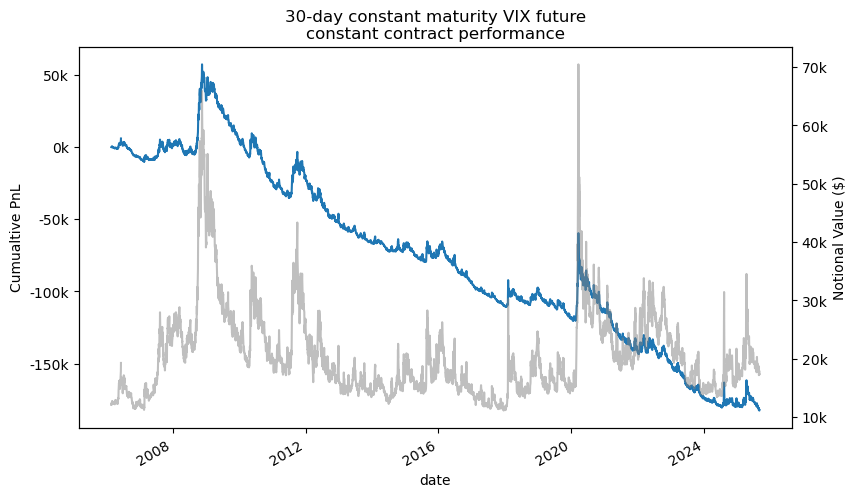

In [8]:
VIX_MULTIPLER = 1e3
CONTRACT_NUM = 1
fig, axes = plt.subplots(1, 1, figsize=(9.2, 5.6 ))
(VIX_MULTIPLER * CONTRACT_NUM * vix_constant_tte_30d['unit_contract_cumpnl']).plot(
    ax=axes, title='30-day constant maturity VIX future\nconstant contract performance')

axes_twin = axes.twinx()
(VIX_MULTIPLER * CONTRACT_NUM * vix_constant_tte_30d['unit_contract_notional']).plot(ax=axes_twin, color='gray', alpha=0.5)

for ax in [axes, axes_twin]:
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k')
    )
axes.set_ylabel('Cumualtive PnL')
axes_twin.set_ylabel('Notional Value ($)')
fig.savefig('30 day VIX futures performance.jpg')